# **09장. 이미지 데이터와 인공 신경망 분류 모델**

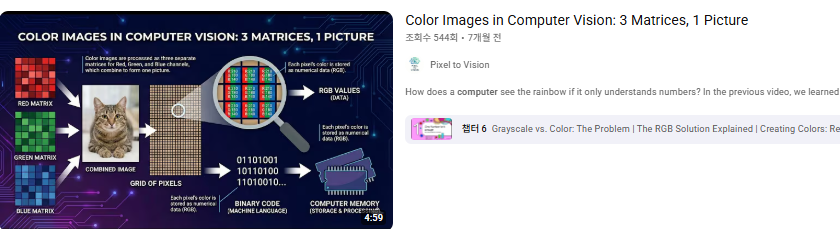

### https://www.youtube.com/watch?v=lAFmfstpq5M

이 동영상은 **3차원 RGB 어레이**를 쉽게 설명해 줍니다.

[실습 09-01]

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np; import pandas as pd;
import matplotlib.pyplot as plt
from PIL import Image
import warnings; warnings.filterwarnings('ignore')

[실습 09-02]

[[[255   0   0]
  [  0 255   0]
  [  0   0 255]]

 [[  0 255 255]
  [255 255   0]
  [255   0 255]]]

차원: 3
형태: (2, 3, 3)


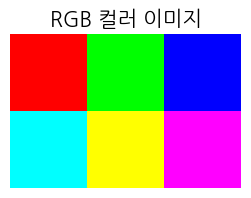

In [ ]:
# 픽셀 값 지정 (3차원 벡터)
어레이1=np.array([[[255, 0,  0], [0,   255, 0], [0,   0, 255]],
                   [[0, 255, 255], [255, 255, 0], [255, 0, 255]]],dtype=np.uint8)
print(어레이1); print()
print("차원:", 어레이1.ndim)    # 3차원
print("형태:", 어레이1.shape)   # (높이, 넓이, 채널) = (2, 3, 3 )

# 배열을 이미지로 출력
plt.figure(figsize=(5, 2))
plt.imshow(어레이1)
plt.title("RGB 컬러 이미지", fontsize=15)
plt.axis("off")   # 축 숫자 제거
plt.show()

[실습 09-03]

In [ ]:
print("R-채널"); print(어레이1[:,:,0]); print()
print("G-채널"); print(어레이1[:,:,1]); print()
print("B-채널"); print(어레이1[:,:,2])

R-채널
[[255   0   0]
 [  0 255 255]]

G-채널
[[  0 255   0]
 [255 255   0]]

B-채널
[[  0   0 255]
 [255   0 255]]


[실습 09-04]

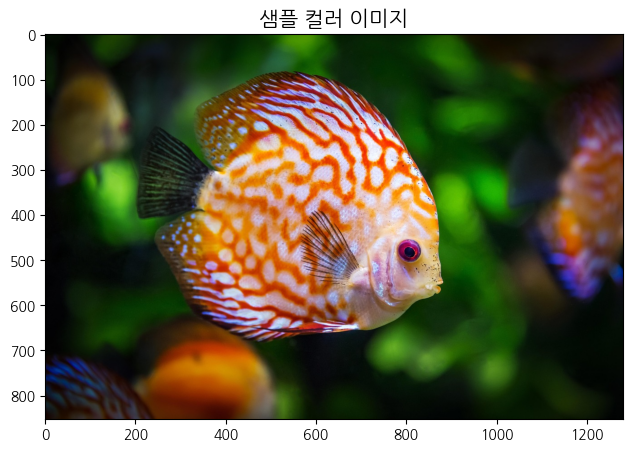

In [ ]:
plt.figure(figsize=(8, 5))
img=Image.open("샘플이미지.jpg")   # 이미지 불러오기
plt.imshow(img)   # 이미지 출력
plt.title("샘플 컬러 이미지", fontsize=15)
plt.show()

[실습 09-05]

In [ ]:
arr=np.array(img)   # 이미지를 어레이로 변환
print("차원= ", arr.ndim); print()
print("형태= ", arr.shape); print()
print("[500,800] 픽셀의 R/G/B 값 =", arr[500,800,:])


차원=  3

형태=  (853, 1280, 3)

[500,800] 픽셀의 R/G/B 값 = [81 20 62]


[실습 09-06]

차원= 2

형태= (853, 1280)

[500, 800] 픽셀값= 43


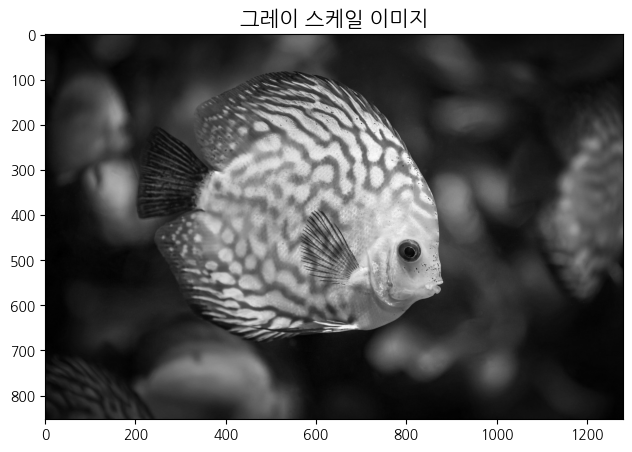

In [ ]:
arr_1=(0.299*arr[:, :, 0] + 0.587*arr[:, :, 1] + 0.114*arr[:, :, 2]).astype(np.uint8) # 가중 평균

print("차원=", arr_1.ndim); print()
print("형태=", arr_1.shape); print()
print("[500, 800] 픽셀값=", arr_1[500,800])

plt.figure(figsize=(8, 5))
plt.title("그레이 스케일 이미지", fontsize=15)
plt.imshow(arr_1, cmap="gray") # 이미지로 출력
plt.show()



---
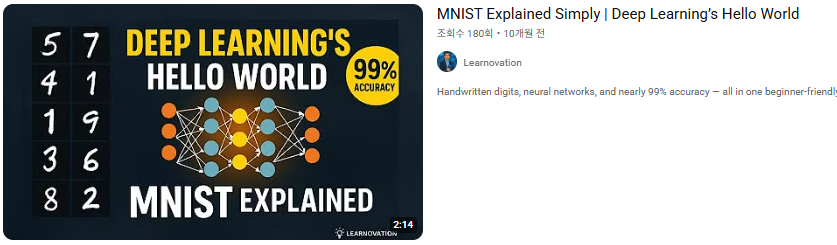



https://www.youtube.com/watch?v=1t6LM5EZlFQ

이 동영상은 MNIST 데이터를 학습하는 절차를 보여줍니다.


---



[실습 09-07]

In [ ]:
import koreanize_matplotlib; import seaborn as sns
import pandas as pd;import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import random
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
import warnings; warnings.filterwarnings('ignore')

[실습 09-08]

In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("훈련용 이미지의 형태 =", x_train.shape); print("훈련용 라벨의 형태 =", y_test.shape)
print("검증용 이미지의 형태 =", x_train.shape); print("검증용 라벨의 형태 =", y_test.shape)


훈련용 이미지의 형태 = (60000, 28, 28)
훈련용 라벨의 형태 = (10000,)
검증용 이미지의 형태 = (60000, 28, 28)
검증용 라벨의 형태 = (10000,)


[실습 09-09]

In [ ]:
print(x_train[0,10:16,10:16]); print()

print("자료형=", type(x_train[1,])); print()
print("차원=", x_train[1, ].ndim)
print("형태=", x_train[1, ].shape)

[[  1 154 253  90   0   0]
 [  0 139 253 190   2   0]
 [  0  11 190 253  70   0]
 [  0   0  35 241 225 160]
 [  0   0   0  81 240 253]
 [  0   0   0   0  45 186]]

자료형= <class 'numpy.ndarray'>

차원= 2
형태= (28, 28)


**Fashion MNIST 데이터셋 불러오기(되새김 문제용)**

In [ ]:
#from keras.datasets.fashion_mnist import load_data
#(x_train, y_train), (x_test, y_test) = load_data()
#class_labels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker','Bag','Ankle boot']
#print(x_train.shape, y_train.shape)

[실습 09-10]

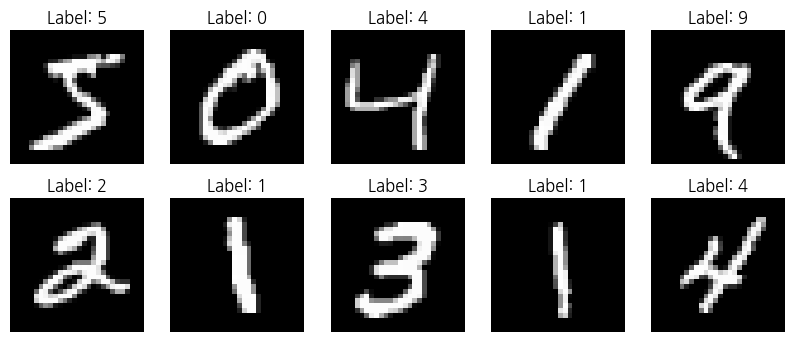

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)               # 2행 5열의 서브플롯
    plt.imshow(x_train[i], cmap="gray")  # 흑백 이미지로 표시
    plt.axis("off")                      # 축 숨기기
    plt.title(f"Label: {y_train[i]}")

plt.show()

[실습 09-11]

In [ ]:
x_train=x_train/255; x_test=x_test/255   # 0~1 데이터전처리
x_test[0, 15:19, 15:19] # 첫 이미지의 일부 픽셀

array([[0.        , 0.52156863, 0.99607843, 0.73333333],
       [0.03529412, 0.80392157, 0.97254902, 0.22745098],
       [0.49411765, 0.99607843, 0.71372549, 0.        ],
       [0.98431373, 0.94117647, 0.22352941, 0.        ]])

[실습 09-12]

In [ ]:
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

MNIST=Sequential([
        Input(shape=(28, 28)),
        Flatten(), # 28x28 차원 벡터로 변환
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
        ])

MNIST.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

[실습 09-13]

In [ ]:
MNIST.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop=EarlyStopping(
              monitor='val_loss', patience=5, restore_best_weights=True)

history=MNIST.fit(x_train, y_train,
              epochs=50,
              validation_data=(x_test, y_test), verbose=1,
              callbacks=[early_stop])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9203 - loss: 0.2779 - val_accuracy: 0.9557 - val_loss: 0.1474
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9618 - loss: 0.1246 - val_accuracy: 0.9655 - val_loss: 0.1109
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9730 - loss: 0.0901 - val_accuracy: 0.9696 - val_loss: 0.0987
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9793 - loss: 0.0688 - val_accuracy: 0.9688 - val_loss: 0.1044
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9837 - loss: 0.0551 - val_accuracy: 0.9706 - val_loss: 0.0973
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9866 - loss: 0.0453 - val_accuracy: 0.9692 - val_loss: 0.1062
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9885 - loss: 0.0379 - val_accuracy: 0.9720 - val_loss: 0.1010
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9902 - loss: 0.0323 

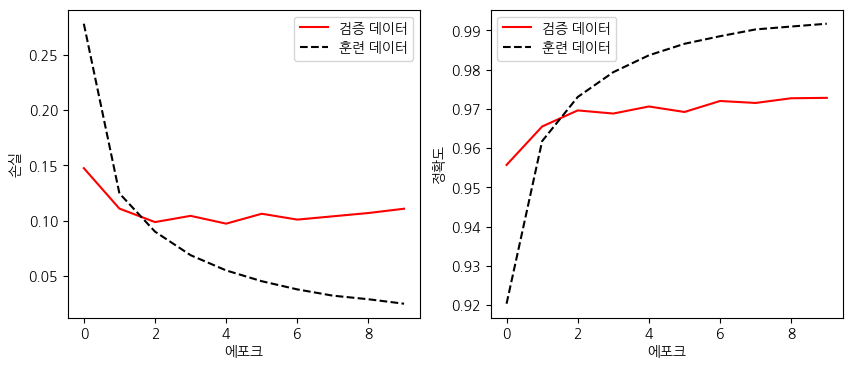

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(history.history['val_loss'], 'r-', label='검증 데이터')
plt.plot(history.history['loss'], 'k--', label='훈련 데이터')
plt.xlabel('에포크'); plt.ylabel('손실')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['val_accuracy'], 'r-', label='검증 데이터')
plt.plot(history.history['accuracy'],'k--',  label='훈련 데이터')
plt.xlabel('에포크'); plt.ylabel('정확도')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


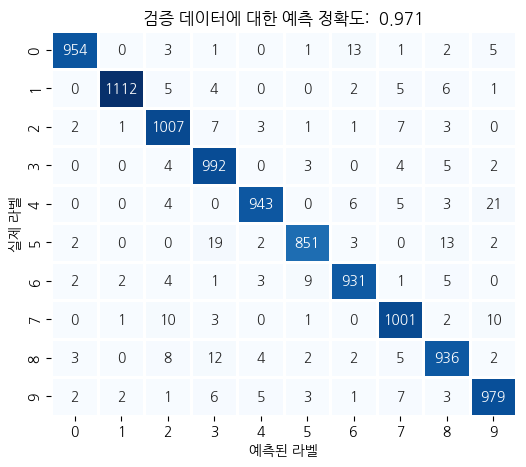

In [ ]:
# 예측
y_prob=MNIST.predict(x_test)      # 클래스별 예측 확률
y_pred=np.argmax(y_prob, axis=1)  # 확률이 가장 큰 클래스 인덱스

# 분류 정확도 계산
acc=accuracy_score(y_test, y_pred)

# 검증용 데이터셋에 대한 혼동행렬 생성
cm=confusion_matrix(y_test, y_pred)

# 혼동행렬 시각화 (이전 코드 재활용)
plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt="d", linewidths=1, cmap='Blues',cbar=None)

# 타깃이 이미 정수 라벨이므로 눈금(ticks) 이름 별도 지정은 불필요

plt.ylabel('실제 라벨'); plt.xlabel('예측된 라벨')
plt.title(f'검증 데이터에 대한 예측 정확도:  {acc:.3f}')
plt.show()

[실습 09-14]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


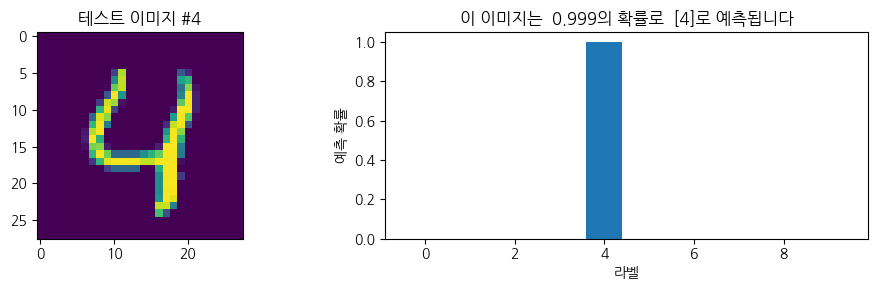

In [ ]:
class_labels=[0,1,2,3,4,5,6,7,8,9]  # 클래스 이름 정의

plt.figure(figsize=(10, 3))
k=4  # 예측 대상 이미지 선택

# 첫 번째 서브플롯: 이미지
plt.subplot(1, 2, 1)
plt.imshow(x_test[k])
plt.title(f"테스트 이미지 #{k}", fontsize=12)

# 예측
y_prob=MNIST.predict(x_test)[k]
y_pred=np.argmax(y_prob)
max_prob=np.max(y_prob)

# 두 번째 서브플롯: 예측 결과
plt.subplot(1, 2, 2)
plt.bar(class_labels, y_prob)
plt.xlabel('라벨')
plt.ylabel('예측 확률')
plt.title(f'이 이미지는 {max_prob: .3f}의 확률로  {[class_labels[y_pred]]}로 예측됩니다', fontsize=12)

plt.tight_layout()
plt.show()